In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

sns.set_theme()

In [2]:
!curl -L -o ./datasets/customer-segmentation-tutorial-in-python.zip\
  https://www.kaggle.com/api/v1/datasets/download/vjchoudhary7/customer-segmentation-tutorial-in-python
!unzip -o ./customer-segmentation-tutorial-in-python.zip -d datasets

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  1583  100  1583    0     0   3418      0 --:--:-- --:--:-- --:--:--  3418
unzip:  cannot find or open ./customer-segmentation-tutorial-in-python.zip, ./customer-segmentation-tutorial-in-python.zip.zip or ./customer-segmentation-tutorial-in-python.zip.ZIP.


In [4]:
data = pd.read_csv("datasets/Mall_Customers.csv")

In [5]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
data.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [7]:
data.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [14]:
data.rename(columns={'Annual Income (k$)': 'Annual Income','Spending Score (1-100)': 'Spending Score'}, inplace=True)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   CustomerID      200 non-null    int64
 1   Gender          200 non-null    str  
 2   Age             200 non-null    int64
 3   Annual Income   200 non-null    int64
 4   Spending_Score  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [15]:
data.duplicated().sum()

np.int64(0)

In [19]:
plt.figure(figsize=(10, 6))

X = data[['Annual Income', 'Spending Score']].to_numpy()
iso_forest = IsolationForest(contamination=0.1, random_state=37)
labels = iso_forest.fit_predict(X)

<Figure size 1000x600 with 0 Axes>

In [20]:
print(type(labels))

<class 'numpy.ndarray'>


In [25]:
normal_points = X[labels == 1]
anomalous_points = X[labels == -1]

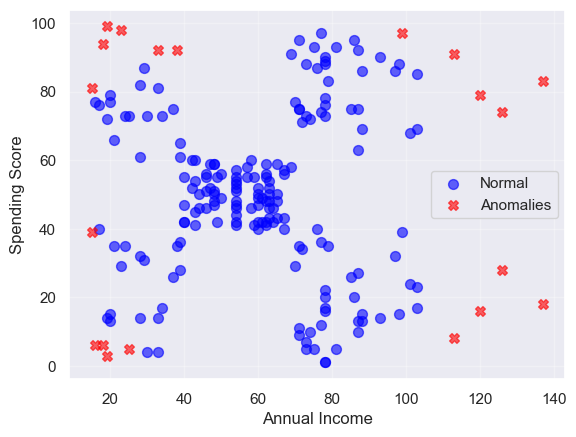

In [31]:
plt.scatter(normal_points[:, 0], normal_points[:, 1], alpha=0.6, s=50, c='blue', label='Normal')
# Plot anomalous points in red
plt.scatter(anomalous_points[:, 0], anomalous_points[:, 1], alpha=0.6, s=50, c='red', marker="X", label='Anomalies')

plt.xlabel('Annual Income')
plt.ylabel("Spending Score")
plt.legend()
plt.grid(True,alpha=0.3)


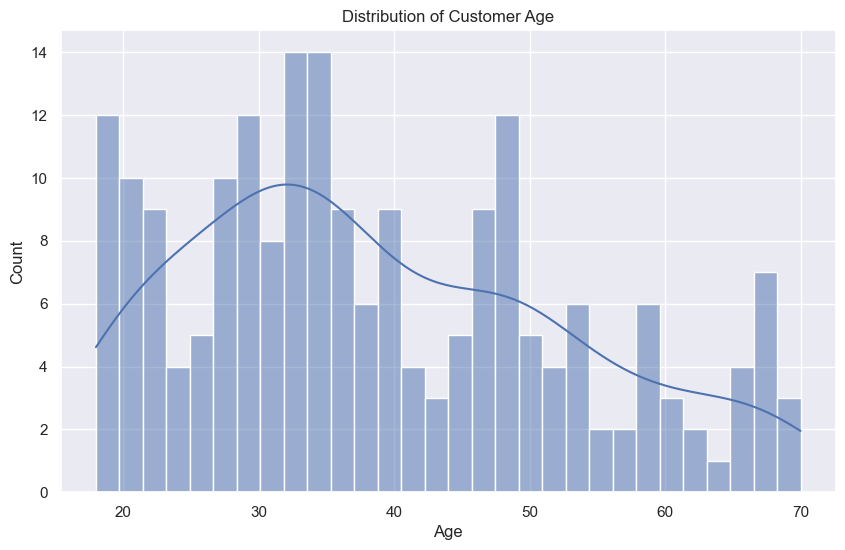

In [36]:
plt.figure(figsize=(10, 6))
sns.histplot(data['Age'], bins=30, kde=True)
plt.title("Distribution of Customer Age")
plt.show()

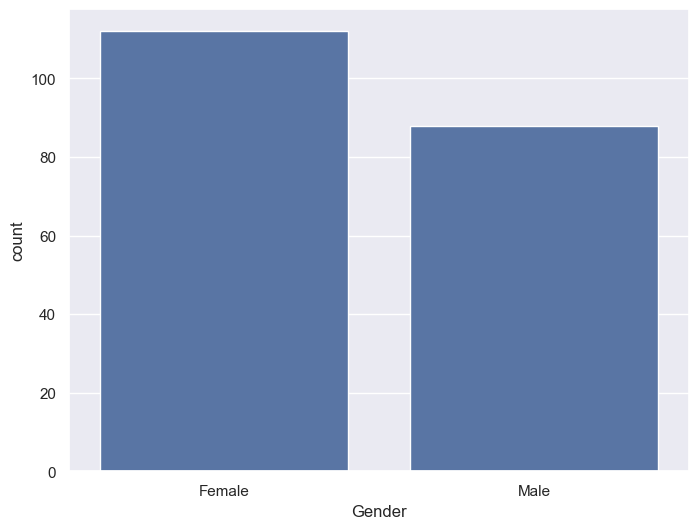

In [51]:
plt.figure(figsize=(8, 6))
gender_counts = data['Gender'].value_counts().reset_index()
sns.barplot(x='Gender', y='count', data=gender_counts)
plt.show()

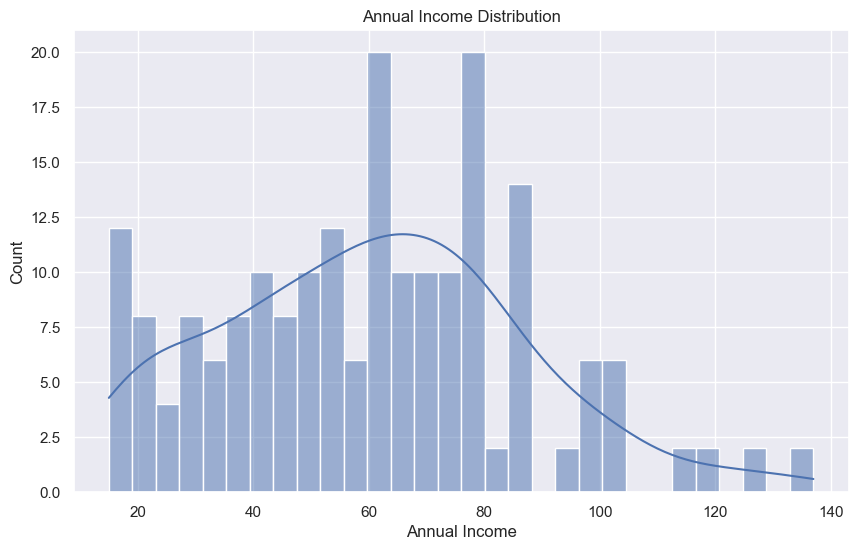

In [52]:
plt.figure(figsize=(10, 6))
sns.histplot(data['Annual Income'], bins=30, kde=True)
plt.title("Annual Income Distribution")
plt.show()


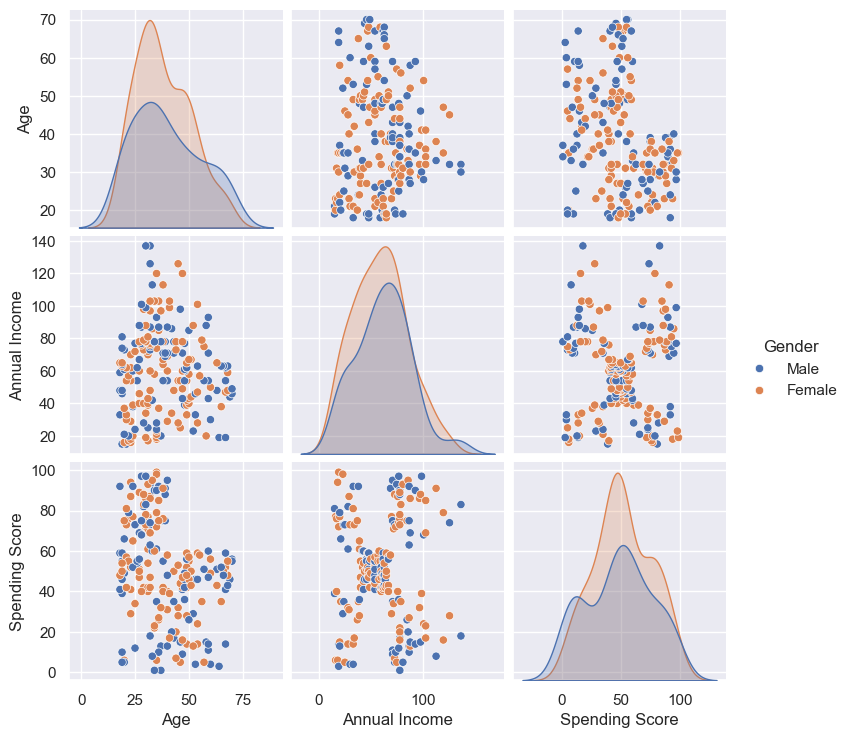

In [53]:
sns.pairplot(data.drop(columns='CustomerID'), hue='Gender')

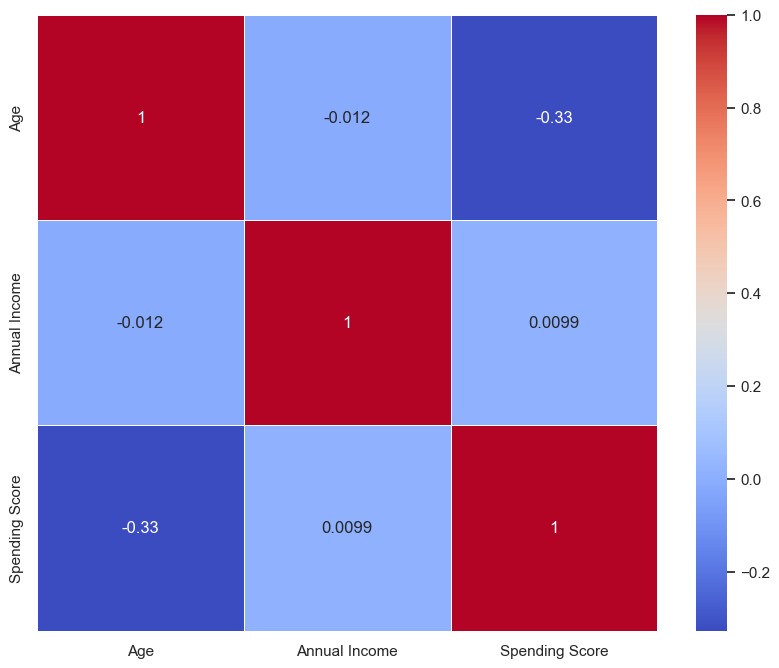

In [56]:
plt.figure(figsize=(10,8))
numeric_data = data.drop(columns='CustomerID').select_dtypes(include=[np.number])
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()

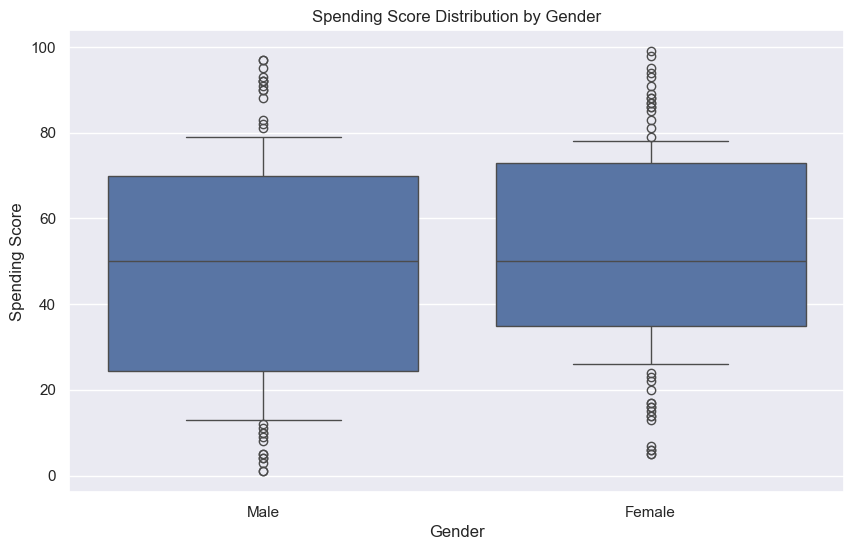

In [69]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Gender', y='Spending Score', data=data, legend='brief', whis=[15, 85])
# sns.violinplot(x="Gender", y="Spending Score", data=data, inner=None, color=".8")
plt.title('Spending Score Distribution by Gender')
plt.show()

Empty DataFrame
Columns: [CustomerID, Gender, Age, Annual Income, Spending Score, Anomaly]
Index: []
<Axes.ArtistList of 0 artists>


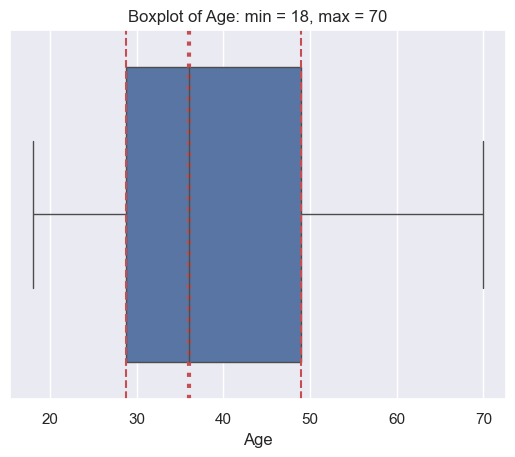

In [95]:
df = data
q1 = df['Age'].quantile(0.25)
q3 = df['Age'].quantile(0.75)
med = df['Age'].median()
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df['Age'] < lower) | (df['Age'] > upper)]
print(outliers)

min_age, max_age = data['Age'].min(), data['Age'].max()
ax = sns.boxplot(x=data['Age'])
ax.axvline(q1, color='r', ls='--')
ax.axvline(med, color='r', ls=':', lw=3)
ax.axvline(q3, color='r', ls='--')
print(ax.artists)
plt.title(f'Boxplot of Age: min = {min_age}, max = {max_age}')
plt.show()

<class 'pandas.Series'>
[137 137]
lower = -13.25, upper = 132.75


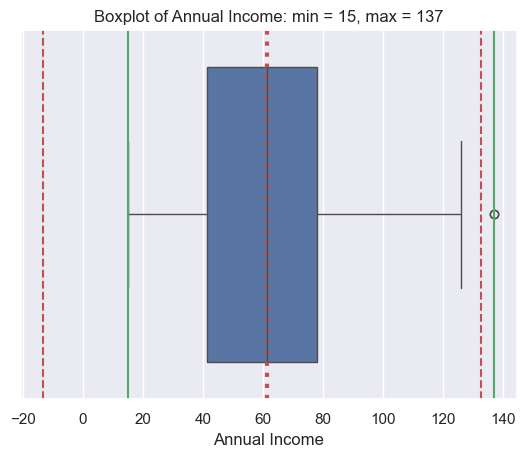

In [107]:
df = data['Annual Income']
print(type(df))
q1 = df.quantile(.25)
q3 = df.quantile(.75)
med = df.median()
iqr = q3-q1

lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

outliers = df[(df < lower) | (df > upper)]
print(outliers.values)
print(f"lower = {lower}, upper = {upper}")

min_age, max_age = df.min(), df.max()
ax = sns.boxplot(x=df)
ax.axvline(df.min(), color='g')
ax.axvline(df.max(), color='g')
ax.axvline(lower, color='r', ls='--')
ax.axvline(med, color='r', ls=':', lw=3)
ax.axvline(upper, color='r', ls='--')
plt.title(f'Boxplot of Annual Income: min = {min_age}, max = {max_age}')
plt.show()

<class 'pandas.Series'>
[]
lower = -22.625, upper = 130.375


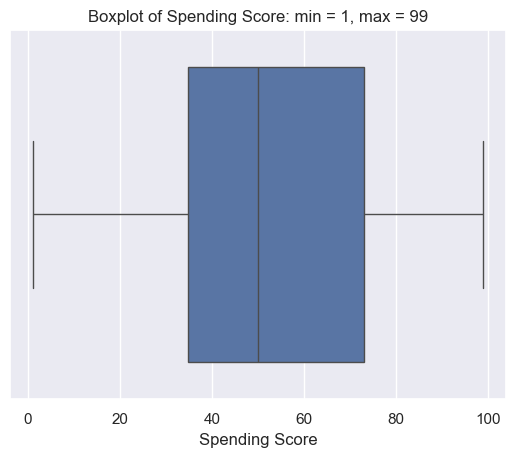

In [109]:
df = data['Spending Score']
print(type(df))
q1 = df.quantile(.25)
q3 = df.quantile(.75)
med = df.median()
iqr = q3-q1

lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

outliers = df[(df < lower) | (df > upper)]
print(outliers.values)
print(f"lower = {lower}, upper = {upper}")

min_age, max_age = df.min(), df.max()
ax = sns.boxplot(x=df)
# ax.axvline(df.min(), color='g')
# ax.axvline(df.max(), color='g')
# ax.axvline(lower, color='r', ls='--')
# ax.axvline(med, color='r', ls=':', lw=3)
# ax.axvline(upper, color='r', ls='--')
plt.title(f'Boxplot of Spending Score: min = {min_age}, max = {max_age}')
plt.show()

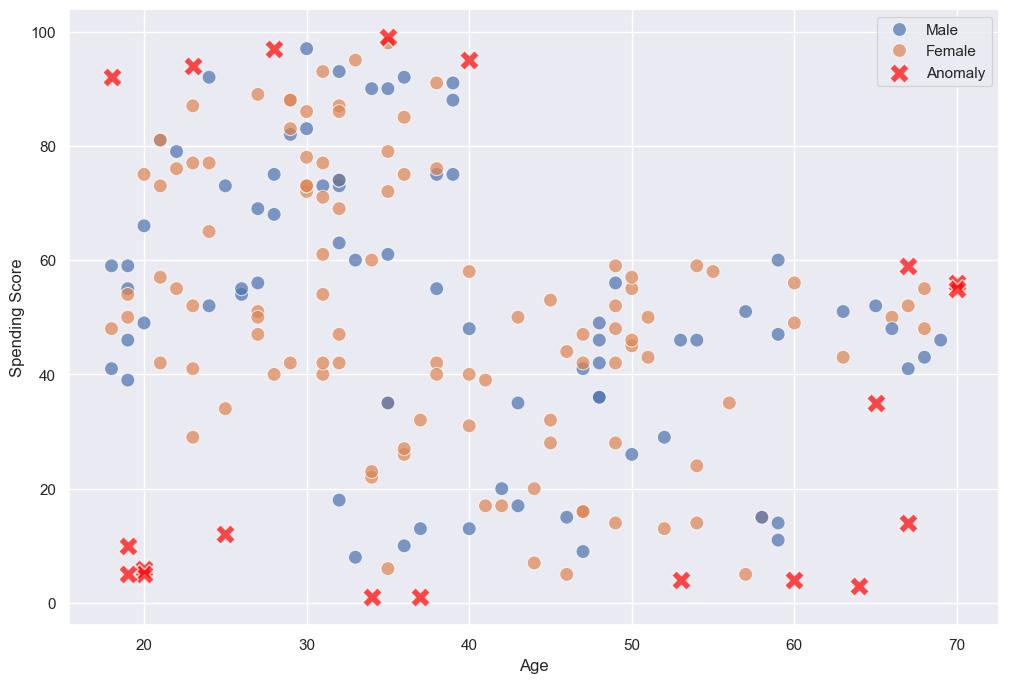

In [80]:
plt.figure(figsize=(12, 8))
X = data[['Age', 'Spending Score']].to_numpy()

iso_forest = IsolationForest(contamination=0.1, random_state=37)
labels = iso_forest.fit_predict(X)

data['Anomaly'] = labels

sns.scatterplot(x='Age', y='Spending Score', hue='Gender', data=data[data['Anomaly'] == 1],
               alpha=.7, s=100)
sns.scatterplot(x='Age', y='Spending Score', data=data[data['Anomaly'] == -1],
               alpha=.7, s=200, c='red', marker='X', label='Anomaly')
plt.show()